In [4]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
from langgraph.types import interrupt, Command
from langchain_core.messages import SystemMessage, HumanMessage,BaseMessage,AnyMessage,AIMessage
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [7]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = InMemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

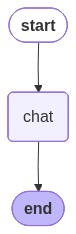

In [8]:
app

In [9]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [10]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', id='238181ea-0f90-4226-b89e-33df77bebfb9')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='0dd61e7b31bd64d4dd44e82773c49a3c')]}

In [11]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [14]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [15]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [16]:
print(final_result["messages"][-1].content)

Not approved.
